# SPR virtual sensor — reproducible experimental analysis

This notebook connects the measured data to **every figure and table** in the
paper and supplement. The reference experiment supplies the kinetic model.
The approximately 25-minute experiment tests the duration selected from the
reference; we do **not** fit a kinetic model or apply a stopping gate to it.

Primary inputs are processed CSVs plus small original vendor kinetics binaries.
Raw reflectance `.spr2` files are intentionally excluded. Their extraction code
and fixed settings are included, and reconstruction was checked locally against
the CSVs before packaging. Mathematical derivations are in the manuscript source.

**Execution:** Run All for the standard reproducibility path. Optional full
bootstrap and hardware benchmarking are disabled by default and explained below.
All new files go to `outputs/`; preserved publication results remain in `results/`.

In [1]:
from pathlib import Path
import sys, json, platform, inspect, subprocess
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "src/kinetics_diagnostics.py").is_file())
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "scripts"))
import numpy as np
import pandas as pd
import scipy
import matplotlib
from IPython.display import display, Markdown, Image
from paths import REF, VAL, OUTPUT
from data_access import read_spr2
from run_analysis import baseline_zero, causal_arrival
from kinetics_diagnostics import fit_tail, derivative_table
print({"Python": platform.python_version(), "NumPy": np.__version__,
       "SciPy": scipy.__version__, "pandas": pd.__version__,
       "matplotlib": matplotlib.__version__})
print("Inputs: data/ | Published results: results/ | Reruns: outputs/")

{'Python': '3.12.14', 'NumPy': '2.5.3', 'SciPy': '1.18.1', 'pandas': '3.0.5', 'matplotlib': '3.11.1'}
Inputs: data/ | Published results: results/ | Reruns: outputs/


## 1. Experimental design and data inventory

Both runs used 1 mM Sulfo-NHS-SS-Biotin in PBS 1X, serial flow at 10 µL/min,
and water rinse, on different sensors. Wavelengths sharing a physical flow cell
are correlated readouts, not independent sensor replicates. Injection-relative
time is the operator clock; local TIR midpoint timing is a separate diagnostic.

In [2]:
channels = pd.DataFrame({"readout": ["L1", "L2", "L3", "L5"],
    "physical_channel": [1, 1, 2, 2], "wavelength_nm": [670, 785, 670, 785]})
display(channels)
reference = read_spr2("reference")
validation = read_spr2("validation")
display(pd.DataFrame([{"experiment": name, "scans_per_readout": len(ds.binary_table[ds.binary_table.channel_id == 0])}
    for name, ds in [("reference", reference), ("validation", validation)]]))
display(pd.read_csv(ROOT / "data/reference/processed/L1_Weighted_centroid_Vendor_TIR_(hybrid).csv").head(3))

,readout,physical_channel,wavelength_nm
0,L1,1,670
1,L2,1,785
2,L3,2,670
3,L5,2,785


,experiment,scans_per_readout
0,reference,830
1,validation,672


,scan_index,channel_id,time_min,direction,DipDepth,CentroidWidthMotor,RawMinimumMotor,SPRMotor,SPRQuality,TIREdgeSlope,...,TIRQuality,DeltaSPRMotor,SPRAngleEmpirical,DeltaSPRAngle,DeltaTIRMotor,TIRAngleEmpirical,DeltaTIRAngle,BulkSensitivity,PureKineticsCandidate,AngleCalibrationRMSEDeg
0,0,0,0.144483,Forward,0.103159,469.063634,19855.0,19863.126242,ok,0.000526,...,ok,-96.824936,68.962173,-0.137814,-64.058614,61.106144,-0.091177,1.593436,0.007470,0.011382
1,1,0,0.280317,Forward,0.103431,470.032572,19865.0,19862.472067,ok,0.000527,...,ok,-97.479111,68.961242,-0.138746,-64.557114,61.105434,-0.091887,1.593436,0.007670,0.011382
2,2,0,0.415900,Forward,0.103658,470.389279,19850.0,19862.395004,ok,0.000523,...,ok,-97.556173,68.961132,-0.138855,-64.961811,61.104858,-0.092463,1.593436,0.008478,0.011382


## 2. Angular processing and bulk correction

Each angular curve was smoothed spatially (21 points, polynomial order 3),
followed by weighted-centroid dip extraction. Vendor TIR provides the hybrid
bulk reference. No temporal smoothing of the corrected kinetics is introduced.

The corrected response is $R=\Delta\theta_{SPR}-S\Delta\theta_{TIR}$.
The baseline for kinetics is the last minute before injection. The noise
comparison uses the separate 10–30 min reference baseline interval.
The coefficient and empirical angular map are fixed before processing the
validation record. The source shows the exact implementation.

In [3]:
from curve_processing import ProcessingConfig, process_channel, noise_metrics
settings = json.loads((ROOT / "data/settings/L1_Weighted_centroid_Vendor_TIR_(hybrid).settings.json").read_text())
display(settings["settings"])
print(inspect.getsource(noise_metrics))
print("Full scan extraction code: src/curve_processing.py")

{'spr_lo': 19355.0,
 'spr_hi': 20355.0,
 'tir_lo': 14260.0,
 'tir_hi': 14710.0,
 'smooth_points': 21,
 'fit_points': 21,
 'centroid_fraction': 0.3,
 'spr_method': 'Weighted centroid',
 'tir_method': 'Vendor TIR (hybrid)',
 'baseline_start': 10,
 'baseline_end': 30}

def noise_metrics(table, start, end):
    """Descriptive short-term noise, not an accuracy or kinetic-fidelity score."""
    w = table[table.time_min.between(start, end)]
    result = {'samples': len(w)}
    for field in ('DeltaSPRAngle', 'DeltaTIRAngle', 'PureKineticsCandidate'):
        v = w[field].to_numpy(float)
        delta = np.diff(v)
        delta = delta[np.isfinite(delta)]
        result[field] = float(1.4826*np.median(np.abs(delta-np.median(delta)))/np.sqrt(2)) if len(delta) >= 5 else None
    return result

Full scan extraction code: src/curve_processing.py


Optional raw reconstruction (outside the default CSV workflow):

```bash
python scripts/process_raw.py reference /path/to/reference.spr2
python scripts/process_raw.py validation /path/to/validation.spr2
```

The calibration was derived retrospectively from the reference scan/vendor
mapping. A causal downstream fit does not make this calibration prospective.

## 3. Derivatives, reference point estimates and baseline noise

Two-minute trailing OLS slopes use Newey–West covariance estimates. Computing
the corrected slope from paired SPR/TIR samples preserves covariance. A small
mean alone is not the sustained confidence-band equivalence criterion.

The estimator is a free-offset exponential tail, $R=b+A(1-e^{-k(t-t_0)})$,
with $\tau=1/k$ (consistent time units). Its parameters describe apparent
relaxation; this is not independent identification of $k_a$, $k_d$, or affinity.
The following cell recomputes the main noise/slopes/rate values and verifies
causality by perturbing only observations after the fit cutoff.

In [4]:
from verify_results import run as verify_results
main_values = verify_results()
display(main_values.round(6))

,readout,vendor_noise_mdeg,centroid_noise_mdeg,noise_reduction_pct,kobs_per_s,tau_min,T99_after_injection_min,mean_corrected_slope
0,L1,0.589886,0.467929,20.674662,0.008251,2.019886,16.468270,-0.123208
1,L2,0.413559,0.244660,40.840420,0.008703,1.915016,15.985323,0.054664
2,L3,0.708876,0.271184,61.744490,0.003942,4.227584,23.924760,0.578185
3,L5,0.343719,0.237830,30.806949,0.004206,3.962123,22.702268,0.374220


In [5]:
print(inspect.getsource(fit_tail))

def fit_tail(time_min, response_mdeg, start_min, end_min):
    t,y=np.asarray(time_min,float),np.asarray(response_mdeg,float)
    use=(t>=start_min)&(t<=end_min)&np.isfinite(y)
    tt,yy=t[use],y[use]
    if len(tt)<20 or tt[-1]-tt[0]<2:
        raise ValueError('Select at least 20 association samples spanning at least 2 minutes.')
    x=(tt-tt[0])*60
    scale=max(float(np.ptp(yy)),1.)
    candidates=[]
    for rate in (.0005,.002,.01,.05):
        r=least_squares(lambda p:tail_model(p,x)-yy,[yy[0],scale,rate],
                        bounds=([-2000.,0.,1e-6],[2000.,2000.,.5]),
                        x_scale='jac',max_nfev=1500)
        if r.success: candidates.append(r)
    if not candidates: raise ValueError('Association-tail fit did not converge.')
    best=min(candidates,key=lambda r:np.sum(r.fun**2))
    b,A,k=best.x
    fitted=tail_model(best.x,x)
    residual=yy-fitted
    bound=bool(k<=1.01e-6 or k>=.499 or A>=1999 or A<.1)
    return dict(start_min=float(tt[0]),end_min=float

## 4. Prefix uncertainty and the reference stopping criterion

The reported fit cutoff is 15.59 min after reference injection. Saved 120-draw
moving-block bootstrap results and successive-prefix fits are preserved below.
The default notebook recomputes point fits but reads these historical bootstrap
exports. Set `FULL_REFERENCE_REFIT=True` to recompute every bootstrap and prefix.
This may take several minutes. The gate is assessed only on the reference run.

In [6]:
FULL_REFERENCE_REFIT = False
if FULL_REFERENCE_REFIT:
    subprocess.run([sys.executable, str(ROOT / "src/association_plateau.py")], check=True, cwd=ROOT)
rates = pd.read_csv(REF / "plateau_results/rate_and_plateau_summary.csv")
display(rates[rates.source == "Centroid + vendor TIR"][["channel", "kobs_per_s", "tau_min",
    "tau_min_bootstrap95", "t99_experiment_min_bootstrap95", "joint_exploratory_trigger_min"]])
display(pd.read_csv(REF / "plateau_results/slope_threshold_sensitivity.csv"))

,channel,kobs_per_s,tau_min,tau_min_bootstrap95,t99_experiment_min_bootstrap95,joint_exploratory_trigger_min
1,L1 670nm,0.008251,2.019886,"[0.873749054885114, 4.988890397415596]","[47.60224643092553, 66.55317265267392]",NaN
3,L2 785nm,0.008703,1.915016,"[0.9321575689283655, 3.9790010276196255]","[47.87122757840538, 61.902460235743206]",NaN
5,L3 670nm,0.003942,4.227584,"[3.1965266820695986, 5.815676090231279]","[55.58869937498235, 67.65032814209688]",NaN
7,L5 785nm,0.004206,3.962123,"[2.8064991621312894, 6.030055781375913]","[53.79255626844757, 68.63758310423748]",NaN


,channel,source,slope_margin_mdeg_min,first_sustained_min
0,L1 670nm,Vendor,0.2,NaN
1,L1 670nm,Vendor,0.5,NaN
2,L1 670nm,Vendor,1.0,NaN
3,L1 670nm,Centroid + vendor TIR,0.2,NaN
4,L1 670nm,Centroid + vendor TIR,0.5,NaN
5,L1 670nm,Centroid + vendor TIR,1.0,57.097117
6,L2 785nm,Vendor,0.2,NaN
7,L2 785nm,Vendor,0.5,NaN
8,L2 785nm,Vendor,1.0,57.367250
9,L2 785nm,Centroid + vendor TIR,0.2,NaN


## 5. Serial delivery and local clocks

Logistic-front fits with drift identify 10%, 50%, and 90% TIR exchange times.
These are refractive-index markers, not direct active-reagent concentration.
Fit fronts are used to separate delivery offsets from relaxation and align the
post-rinse comparison. The following recomputes all reference transition fits.

In [7]:
import contextlib, io
import serial_delivery
with contextlib.redirect_stdout(io.StringIO()):
    serial_delivery.main()
delays = pd.read_csv(REF / "serial_results/inter_trace_delays.csv")
display(delays[delays.early_trace.isin(["L3 670nm", "L5 785nm"]) &
               delays.late_trace.isin(["L1 670nm", "L2 785nm"])])

,edge,early_trace,late_trace,t50_delay_min,apparent_volume_uL,shift_fit_delay_min,shift_fit_rmse_mdeg
0,PBS rise,L3 670nm,L1 670nm,2.215475,22.154746,2.177362,1.296125
1,PBS rise,L5 785nm,L2 785nm,2.220732,22.207321,2.184450,1.362236
6,PBS decline,L3 670nm,L1 670nm,2.185422,21.854219,2.215487,1.158221
7,PBS decline,L5 785nm,L2 785nm,2.195270,21.952695,2.206857,0.879346
12,Biotin rise,L3 670nm,L1 670nm,2.248841,22.488407,2.235255,1.298689
13,Biotin rise,L5 785nm,L2 785nm,2.245378,22.453781,2.232911,1.093922
18,Water-associated decline,L3 670nm,L1 670nm,2.236471,22.364707,2.194388,0.693884
19,Water-associated decline,L5 785nm,L2 785nm,2.256476,22.564762,2.212972,0.806065


## 6. Reference-selected validation duration and retained outcomes

The reference's maximum point forecast is approximately 23.92 min. It motivated
the approximately 25-minute programmed exposure on the second sensor. The new
record is evaluated **only through measured response, delivered-exposure proxy,
and retained endpoint**. No validation-run kinetic fit is imported or executed.

We recompute all 36 endpoint comparisons: four readouts, three rinse-age windows,
and three baseline/processing conventions. A positive retained signal and an
endpoint equal to the reference are different outcomes.

In [8]:
from validation_outcomes import run as validation_outcomes
endpoints = validation_outcomes()
display(endpoints[(endpoints.method == "centroid") & (endpoints.rinse_age_start_min == 15)])
display(pd.read_csv(VAL / "exposure_comparison.csv")[["channel", "midpoint_exposure_min", "reference_midpoint_exposure_min"]])

,channel,method,rinse_age_start_min,rinse_age_end_min,short_mean_mdeg,reference_mean_mdeg,difference_mdeg,short_over_reference,short_within_window_sd,reference_within_window_sd,short_samples,reference_samples
1,L1,centroid,15,20,20.667831,31.193868,-10.526037,0.662561,0.644114,1.036515,37,37
10,L2,centroid,15,20,12.812643,19.144905,-6.332262,0.669246,0.281727,0.428113,37,37
19,L3,centroid,15,20,7.122553,30.852249,-23.729696,0.230860,0.715097,1.264825,37,37
28,L5,centroid,15,20,4.387506,18.048433,-13.660927,0.243096,0.293566,0.734512,37,37


,channel,midpoint_exposure_min,reference_midpoint_exposure_min
0,L1,24.514963,24.773909
1,L2,24.534254,24.801557
2,L3,24.566879,24.786279
3,L5,24.571039,24.790459


In [9]:
display(endpoints[["channel", "method", "rinse_age_start_min", "short_mean_mdeg",
                   "reference_mean_mdeg", "difference_mdeg", "short_over_reference"]])

,channel,method,rinse_age_start_min,short_mean_mdeg,reference_mean_mdeg,difference_mdeg,short_over_reference
0,L1,centroid,10,23.045275,35.187053,-12.141778,0.654936
1,L1,centroid,15,20.667831,31.193868,-10.526037,0.662561
2,L1,centroid,20,21.218487,29.980787,-8.762300,0.707736
3,L1,vendor,10,21.456651,34.268303,-12.811652,0.626137
4,L1,vendor,15,18.772447,30.095868,-11.323422,0.623755
5,L1,vendor,20,19.323733,28.914874,-9.591141,0.668297
6,L1,centroid_initial_water,10,40.463192,28.517720,11.945472,1.418879
7,L1,centroid_initial_water,15,38.085748,24.524535,13.561213,1.552965
8,L1,centroid_initial_water,20,38.636403,23.311454,15.324950,1.657400
9,L2,centroid,10,14.092472,21.193115,-7.100643,0.664955


## 7. Recreate the manuscript figures and normalized-time analysis

This step runs the original plotting logic using portable paths. It recreates
all seven empirical figures and recomputes the equal-local-age normalization
sensitivity. Figure 1 is the original editable TikZ, separately supplied as
`figures/model_diagram.tex`; compiling it requires a LaTeX installation with TikZ.
The previews displayed below are bundled publication renders for GitHub viewing;
the newly generated vector PDFs are saved in `outputs/figures/`.

In [10]:
from reproduce import figures
with contextlib.redirect_stdout(io.StringIO()):
    figures()
display(pd.read_csv(REF / "normalization_results/normalization_summary.csv"))
print("Generated PDFs:", sorted(p.name for p in (OUTPUT / "figures").glob("*.pdf")))

,readout,physical_channel,tau_min,kobs_per_s,arrival50_after_injection_min,fit_start_after_injection_min,relaxation99_from_tail_start_min,T99_after_injection_min,T99_after_arrival50_min,T99_dimensionless,equal_local_age_tau_min,equal_local_age_rmse_mdeg,equal_local_age_parameter_boundary,equal_local_age_amplitude_mdeg
0,L1,1,2.019886,0.008251,6.719977,7.166350,9.301920,16.468270,9.748293,4.60517,0.991171,1.003175,False,4.870349
1,L2,1,1.915016,0.008703,6.708439,7.166350,8.818973,15.985323,9.276885,4.60517,2.285192,0.678892,False,2.415361
2,L3,2,4.227584,0.003942,4.471137,4.456017,19.468743,23.924760,19.453623,4.60517,28.937525,0.919796,False,52.328266
3,L5,2,3.962123,0.004206,4.463061,4.456017,18.246251,22.702268,18.239207,4.60517,72.938538,0.655415,False,57.706859


Generated PDFs: ['main_reference.pdf', 'main_short.pdf', 'normalized_kinetics.pdf', 'serial_fronts.pdf', 'supplement_short_785.pdf', 'supplement_slopes_785.pdf', 'tail_fits.pdf']


### model diagram

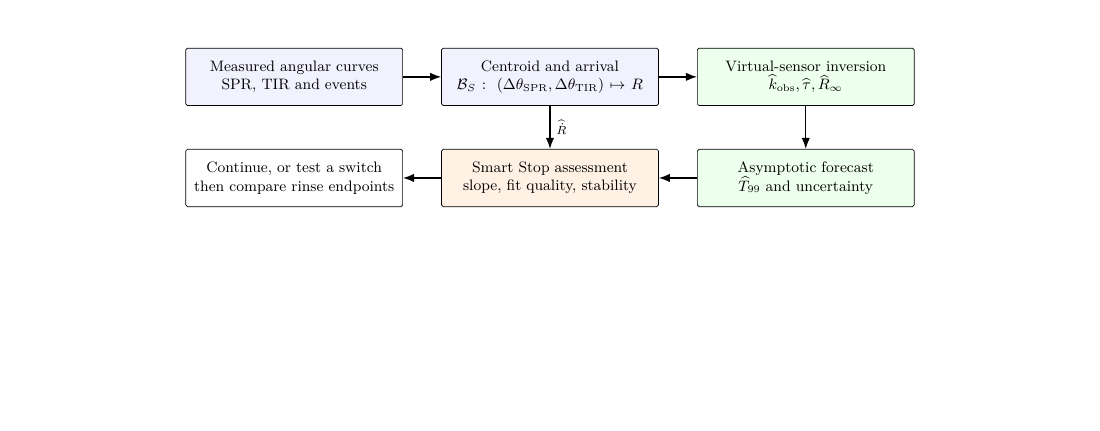

### main reference

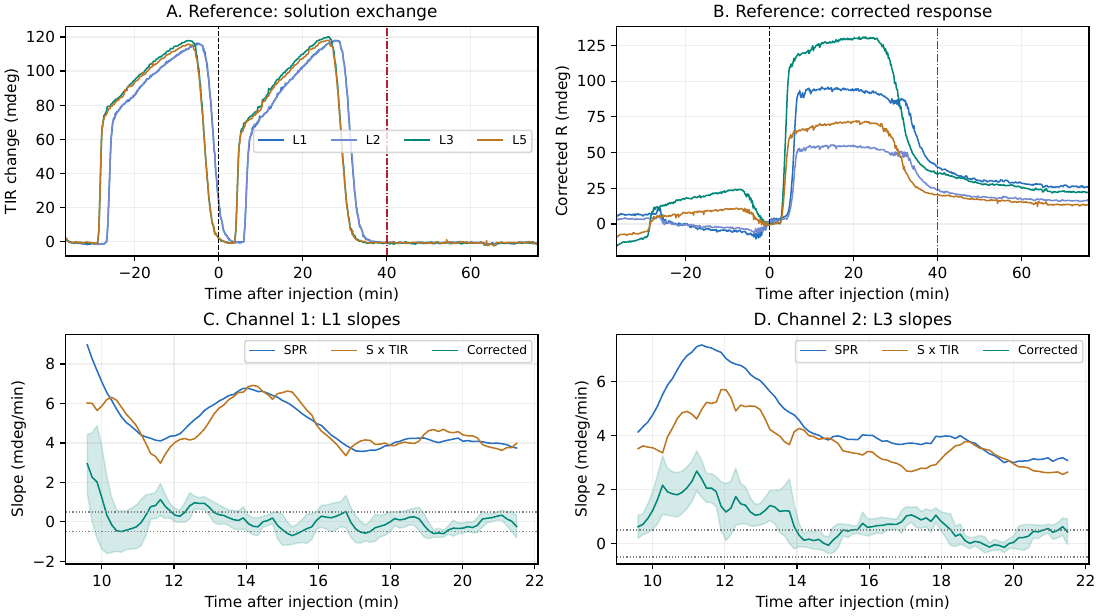

### main short

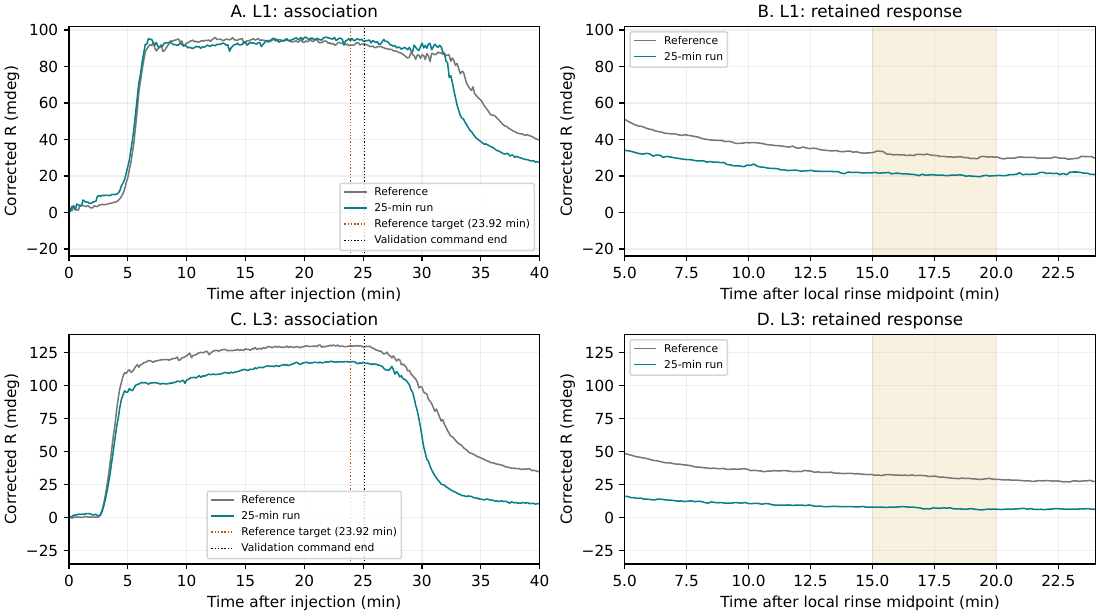

### serial fronts

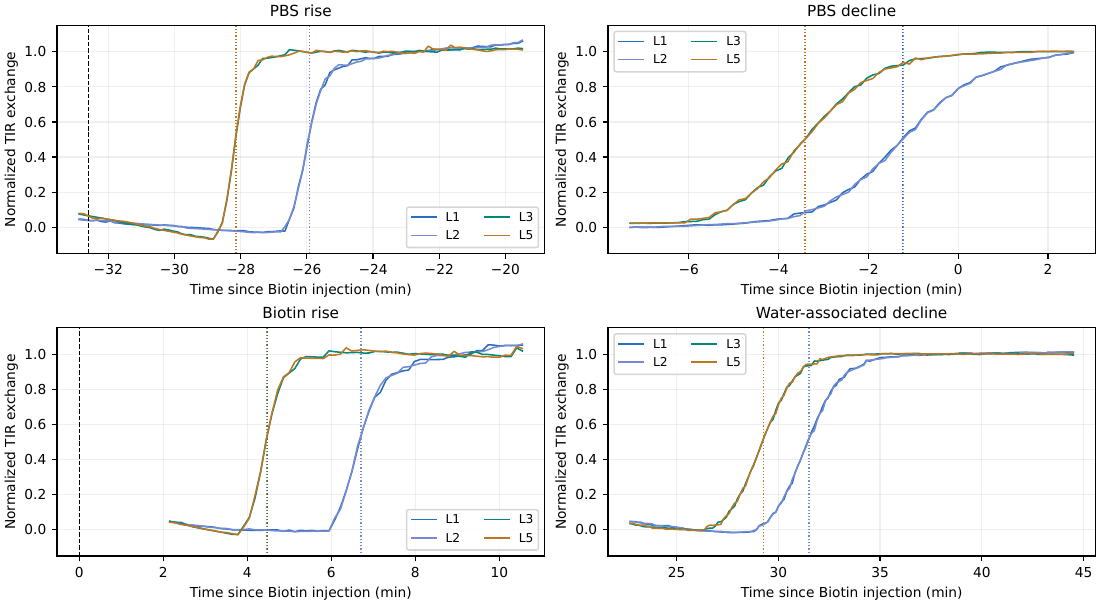

### tail fits

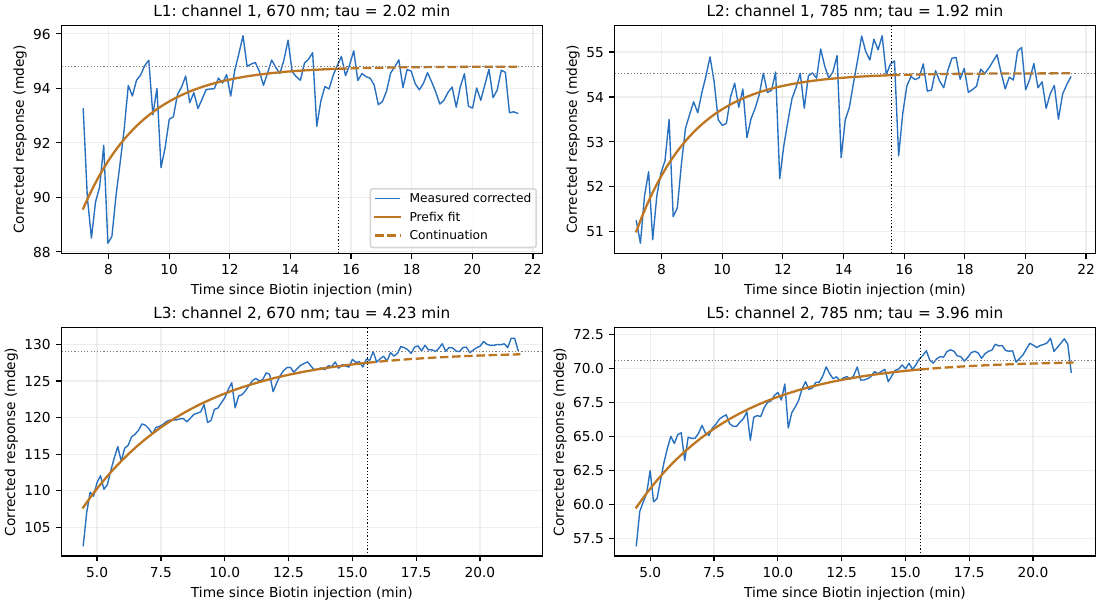

### supplement slopes 785

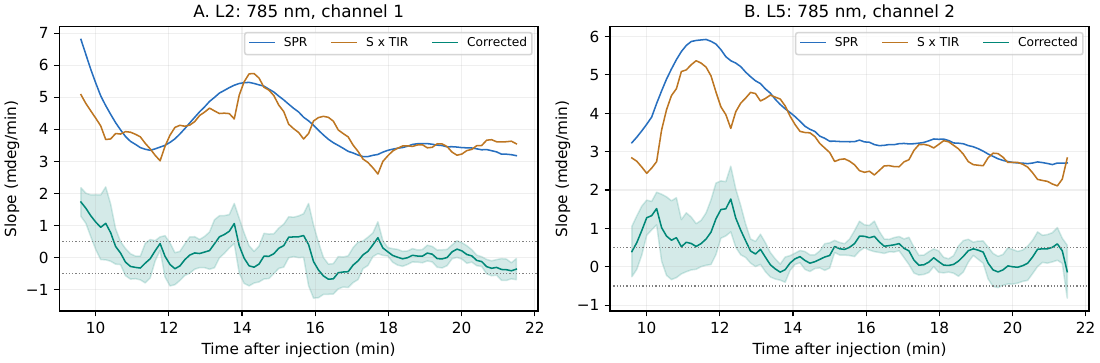

### normalized kinetics

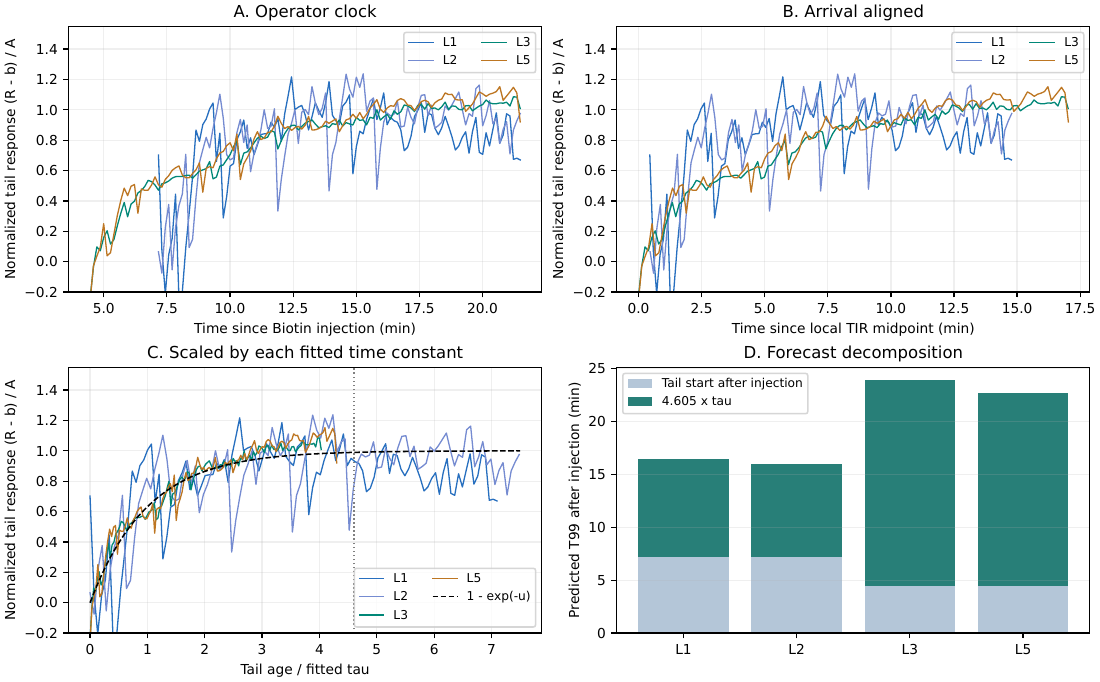

### supplement short 785

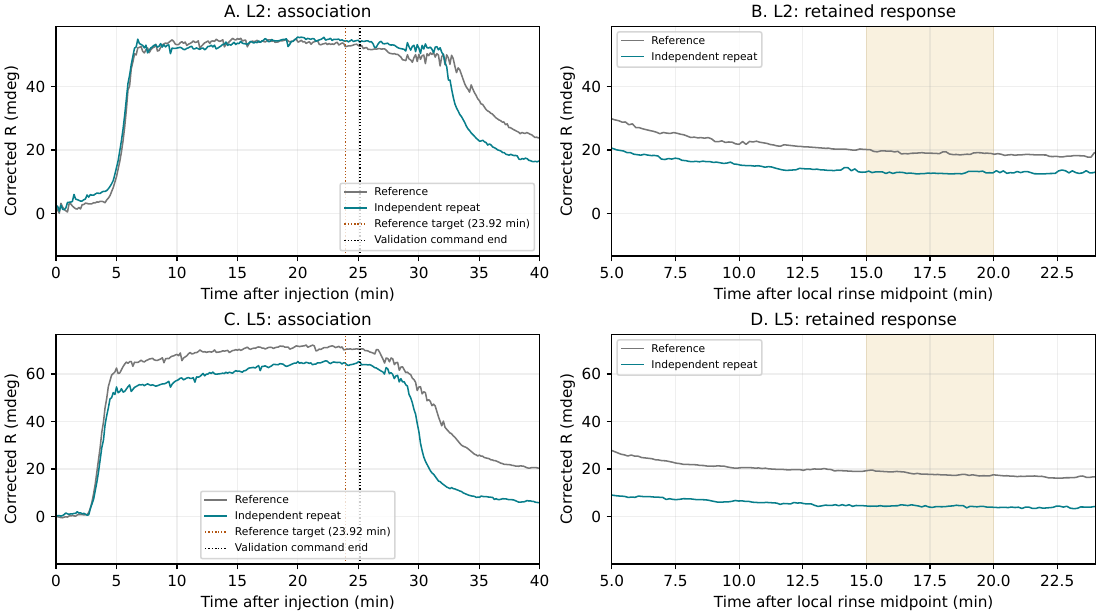

In [11]:
figure_names = ["model_diagram", "main_reference", "main_short", "serial_fronts",
                "tail_fits", "supplement_slopes_785", "normalized_kinetics", "supplement_short_785"]
for name in figure_names:
    display(Markdown("### " + name.replace("_", " ")))
    display(Image(filename=str(ROOT / "figures/previews" / (name + ".png")), width=900))

## 8. Computational cost: historical measurements versus current hardware

The published timing is a historical measurement of the four-readout kernel on
the reference stream, not a hardware-independent constant. Residual counts
include finite-difference callback work; exponential calls are separate from
basic FLOPs. Solver algebra and slope calculation enter elapsed time but are
not included in residual-only FLOP totals. The CSVs expose every measurement.

Set `BENCHMARK_CURRENT_MACHINE=True` to time this machine. The original benchmark
JSON/CSVs remain under `results/`; new measurements go to `outputs/`.

In [12]:
benchmark = json.loads((ROOT / "results/reference/runtime_results/benchmark.json").read_text())
display(benchmark)
latencies = pd.read_csv(ROOT / "results/reference/runtime_results/latency.csv")
operations = pd.read_csv(ROOT / "results/reference/runtime_results/operation_counts.csv")
display(latencies.describe())
display(operations.head())
BENCHMARK_CURRENT_MACHINE = False
if BENCHMARK_CURRENT_MACHINE:
    subprocess.run([sys.executable, str(ROOT / "src/benchmark_streaming.py")], check=True, cwd=ROOT)

{'cpu': '13th Gen Intel(R) Core(TM) i7-13700H',
 'os': 'Windows-11-10.0.26200-SP0',
 'python': '3.12.14',
 'numpy': '2.5.3',
 'scipy': '1.18.1',
 'repetitions': 3,
 'updates_per_replay': 77,
 'readouts_per_update': 4,
 'first_time_after_injection_min': 11.220216666666666,
 'last_time_after_injection_min': 21.495599999999996,
 'latency_ms': {'mean': 36.600901731601724,
  'median': 34.868,
  'p95': 48.8039,
  'maximum': 64.0886},
 'median_scan_spacing_s': 8.118999999999872,
 'minimum_scan_spacing_s': 8.021999999999423,
 'basic_residual_flops': {'mean': 220539.22077922078, 'maximum': 347892},
 'expm1_calls': {'mean': 55134.805194805194, 'maximum': 86973},
 'residual_calls': {'mean': 716.5974025974026, 'maximum': 908},
 'maximum_fit_samples': 127,
 'final_prefix_tracemalloc_peak_bytes': 85387,
 'maximum_tail_time_response_payload_bytes': 7488,
 'published_rate_verification': [0.00825128974304442,
  0.008703148709946776,
  0.003942362143397703,
  0.004206499065999838],
 'scope': 'Four seque

,repeat,index,time_min,latency_ms
count,231.00000,231.000000,231.000000,231.000000
mean,1.00000,389.000000,52.770544,36.600902
std,0.81827,22.274376,3.012201,5.766431
min,0.00000,351.000000,47.632350,29.716900
25%,0.00000,370.000000,50.199733,32.828500
50%,1.00000,389.000000,52.772200,34.868000
75%,2.00000,408.000000,55.340450,38.664450
max,2.00000,427.000000,57.907733,64.088600


,index,residual_calls,residual_point_evaluations,basic_residual_flops,expm1_calls,scalar_negations,nfev,njev,maximum_fit_samples
0,351,902,35342,141368,35342,36244,242,220,51
1,352,903,36516,146064,36516,37419,240,221,52
2,353,889,36977,147908,36977,37866,238,217,53
3,354,855,36750,147000,36750,37605,228,209,54
4,355,827,36705,146820,36705,37532,221,202,55


## 9. Coverage and interpretation

`RESULTS_MAP.md` maps every figure, table, and reference sensitivity result to its
source and export. Data are two experiments on different sensors, not independent
replicates for each wavelength. No synthetic experimental results are used.
Raw angular reconstruction requires the unbundled `.spr2` files. Runtime and
allocation values depend on hardware/software; bootstrap intervals are conditional
on the selected window and model. No repository URL or DOI is asserted before
the authors publish this package.

In [13]:
display(Markdown((ROOT / "RESULTS_MAP.md").read_text(encoding="utf-8")))
print("Completed: CSV-based figure regeneration, point estimates, slope/noise checks,",
      "serial timing, validation endpoints and historical runtime accounting.")

# Complete manuscript result map

| Item | Figure / numerical export | Reproduction source |
|---|---|---|
| Main Fig. 1 | `figures/model_diagram.tex` | Original TikZ from manuscript |
| Main Fig. 2 | `main_reference.pdf` | `compact_paper_figures.py` |
| Main Fig. 3 | `main_short.pdf` | `compact_paper_figures.py`; validation measured CSVs only |
| Supplement Fig. S1 | `serial_fronts.pdf` | `serial_delivery.py`, `paper_figures.py` |
| Supplement Fig. S2 | `tail_fits.pdf` | `association_plateau.py`, `paper_figures.py` |
| Supplement Fig. S3 | `supplement_slopes_785.pdf` | `supplement_only_figures.py` |
| Supplement Fig. S4 | `normalized_kinetics.pdf` | `normalized_analysis.py` |
| Supplement Fig. S5 | `supplement_short_785.pdf` | `supplement_only_figures.py` |
| Main Table I | noise and slopes | `verify_results.py`; original processing method CSVs |
| Main Table II | `reference/plateau_results/rate_and_plateau_summary.csv` | `association_plateau.py`, `kinetics_diagnostics.py` (120 bootstrap draws) |
| Main Table III | `validation/endpoint_comparison.csv`, `exposure_comparison.csv` | `validation_outcomes.py` |
| Main Table IV | `reference/runtime_results/benchmark.json`, latency and operation CSVs | `benchmark_streaming.py`; historical measurements preserved |
| Supplement Table S1 | `reference/serial_results/inter_trace_delays.csv` | `serial_delivery.py` |
| Supplement Table S2 | `reference/normalization_results/normalization_summary.csv` | `normalized_analysis.py` |
| Supplement Tables S3–S5 | `validation/endpoint_comparison.csv` filtered by method and rinse window | `validation_outcomes.py` |
| Reference strict and alternative slope gates | `reference/plateau_results/prefix_k_tau.csv`, `slope_threshold_sensitivity.csv` | `association_plateau.py` |
| Equal-local-age rate sensitivity and paired-wavelength differences | `reference/normalization_results/analysis.json` | `normalized_analysis.py` |
| Model derivations and definitions | main/supplement manuscript source | Analytical expressions; no synthetic-data experiment |

Numerical-export paths above are relative to `results/`; figure filenames are
relative to `figures/`. New runs write corresponding results beneath `outputs/`.
The notebook executes the standard path and displays all eight figures, including
the conceptual TikZ diagram. Bootstrap and hardware profiling are optional cells.


Completed: CSV-based figure regeneration, point estimates, slope/noise checks, serial timing, validation endpoints and historical runtime accounting.
